In [ ]:
# Comparison of normalized and

In [ ]:
import numpy as np
import pandas as pd
import pickle as pkl
import matplotlib.pyplot as plt
import glob
import os
import random
import torch
import re # regular expressions


import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

In [ ]:
from google.colab import drive

In [ ]:
drive.flush_and_unmount()

In [ ]:
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!ls "/content/drive/MyDrive/NNDL_PROGETTO/data_generation/2dof/"

test_data  train_data  val_data


## NETWORK DEFINITION

In [ ]:
class Net(nn.Module):

    def __init__(self, Ni, Nh1, Nh2, No):
        """
        Ni - Input size
        Nh1 - Neurons in the 1st hidden layer
        Nh2 - Neurons in the 2nd hidden layer
        No - Output size
        """
        super().__init__()

        print('Network initialized')
        ###################################################
        ### PUT YOR CODE HERE
        self.fc1 = nn.Linear(Ni, Nh1)
        self.fc2 = nn.Linear(Nh1, Nh2)
        self.out = nn.Linear(Nh2, No)
        self.act = nn.ReLU()
        ###################################################

    def forward(self, x, additional_out=False):
        ###################################################
        ### PUT YOR CODE HERE
        # don't forget the activations: not incuded by default!
        x = self.act(self.fc1(x))
        x = self.act(self.fc2(x))
        x = self.out(x)
        ###################################################
        return x

In [ ]:
class DeepNet(nn.Module):

    def __init__(self, Ni, Nh1, Nh2, Nh3, Nh4, Nh5, No):
        """
        Ni - Input size
        Nh1 - Neurons in the 1st hidden layer
        Nh2 - Neurons in the 2nd hidden layer
        No - Output size
        """
        super().__init__()

        print('Network initialized')
        ###################################################
        self.fc1 = nn.Linear(Ni, Nh1)
        self.fc2 = nn.Linear(Nh1, Nh2)
        self.fc3 = nn.Linear(Nh2, Nh3)
        self.fc4 = nn.Linear(Nh3, Nh4)
        self.fc5 = nn.Linear(Nh4, Nh5)
        self.out = nn.Linear(Nh5, No)

        self.act = nn.ReLU()
        ###################################################

    def forward(self, x, additional_out=False):
        ###################################################
        x = self.act(self.fc1(x))
        x = self.act(self.fc2(x))
        x = self.act(self.fc3(x))
        x = self.act(self.fc4(x))
        x = self.act(self.fc5(x))
        x = self.out(x)
        return x
        ###################################################

## Definizione classe PklDataset

In [ ]:
class PklDataset(Dataset):

    def __init__(self, pkl_folder, random_choice=False, transform=None, normalize_y=False, mean_y=None, std_y=None):
        """
        Args:
            pkl_folder (folder): Path to the folder.
            transform (callable, optional): Optional transform to be applied
                on a sample.
        """
        self.transform = transform
        self.normalize_y = normalize_y

        match = re.search(r"(\d+)dof", pkl_folder)
        if not match:
            raise ValueError(f"Impossibile estrarre i DOF dal nome file: {pkl_folder}")
        self.n_dof = int(match.group(1))

        # Genera le colonne dinamicamente
        columns = []
        for j in range(1, self.n_dof + 1):
            columns += [f"q_{j}", f"dq_{j}", f"ddq_{j}"]
        for j in range(1, self.n_dof + 1):
            columns += [f"tau_noiseless_{j}"]

        # We read all the files one by one and put them inside a list
        pkl_files = glob.glob(os.path.join(pkl_folder,'*.pkl'))
        # TESTING IF IT WORKS
        # ----
        # df_test= pd.read_pickle(pkl_files[0])
        # print(df_test[columns].head())
        # ----
        self.data = []
        all_y = []

        if not random_choice:
          for file_path in pkl_files:
            df = pd.read_pickle(file_path)
            np_array = df[columns].to_numpy()
            X = np_array[:, :(3*self.n_dof)]   # 6 features
            y = np_array[:, (3*self.n_dof):]   # 2 labels
            for i in range(np_array.shape[0]):
              self.data.append((X[i], y[i]))  # tuple (input, label)
            all_y.append(y)

        else:
          random_file = random.choice(pkl_files)
          df = pd.read_pickle(random_file)
          np_array = df[columns].to_numpy()
          X = np_array[:, :(3*self.n_dof)]   # 6 features
          y = np_array[:, (3*self.n_dof):]   # 2 labels
          for i in range(np_array.shape[0]):
            self.data.append((X[i], y[i]))  # tuple (input, label)
          all_y.append(y)

        if normalize_y:
          if mean_y is not None and std_y is not None:
            self.mean_y = mean_y
            self.std_y = std_y
          else:
            all_y = np.vstack(all_y)
            self.mean_y = np.mean(all_y, axis=0)
            self.std_y = np.std(all_y, axis=0)
            self.std_y[self.std_y == 0] = 1 # Trick per gestire divisione per 0
        else:
          self.mean_y = np.zeros(self.n_dof)
          self.std_y = np.ones(self.n_dof)

    def __len__(self):
        # The length of the dataset is simply the length of the self.data list
        return len(self.data)

    def __getitem__(self, idx):
        # Our sample is the element idx of the list self.data
        sample = self.data[idx]

        if self.normalize_y:
            sample = (sample[0], (sample[1] - self.mean_y) / self.std_y)
        if self.transform:
            sample = self.transform(sample)
        return sample

In [ ]:
class ToTensor(object):
    """Convert sample to Tensors."""

    def __call__(self, sample):
        # sample is expected to be a numpy array (a single row from the dataset)
        x = sample[0]
        y = sample[1]
        return (torch.tensor(x).float(),
                torch.tensor(y).float())

composed_transform = transforms.Compose([ToTensor()])

In [ ]:
n_dof= 2


train_dataset = PklDataset(f'/content/drive/MyDrive/NNDL_PROGETTO/data_generation/{n_dof}dof/train_data/', transform=composed_transform, normalize_y=True)
val_dataset = PklDataset(f'/content/drive/MyDrive/NNDL_PROGETTO/data_generation/{n_dof}dof/val_data/', transform=composed_transform, normalize_y=True, mean_y=train_dataset.mean_y, std_y=train_dataset.std_y)
test_dataset = PklDataset(f'/content/drive/MyDrive/NNDL_PROGETTO/data_generation/{n_dof}dof/test_data/', transform=composed_transform, mean_y=train_dataset.mean_y, std_y=train_dataset.std_y)
# Normalizzo il DS di test rispetto alla sua media e std_dev
test_dataset_norm = PklDataset(f'/content/drive/MyDrive/NNDL_PROGETTO/data_generation/{n_dof}dof/test_data/', transform=composed_transform, normalize_y=True)




In [ ]:

print(f"Train dataset mean: {(train_dataset.mean_y)}")
print(f"Val dataset std: {train_dataset.std_y}")
print(f"Test dataset mean: {test_dataset_norm.mean_y}")
print(f"Test dataset std: {test_dataset_norm.std_y}")

Train dataset mean: [ 1.54600172e-04 -2.15040363e+01]
Val dataset std: [ 3.74657504 20.62795749]
Test dataset mean: [ 1.84191714e-04 -2.15196451e+01]
Test dataset std: [ 3.73821106 20.53293937]


In [ ]:
mean_y = train_dataset.mean_y
std_y = train_dataset.std_y
mean_test_y = test_dataset_norm.mean_y
std_test_y = test_dataset_norm.std_y

In [ ]:
train_dataloader = DataLoader(train_dataset, batch_size=64, shuffle=True, num_workers=0)
val_dataloader  = DataLoader(val_dataset,  batch_size=64, shuffle=False, num_workers=0)
test_dataloader  = DataLoader(test_dataset,  batch_size=64, shuffle=False, num_workers=0)
test_dataloader_norm = DataLoader(test_dataset_norm, batch_size=64, shuffle=False, num_workers=0)

In [ ]:
# Check if the GPU is available
device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
print(f"Training device: {device}")

Training device: cpu


In [ ]:
# # Initialize the network
# torch.manual_seed(0)
# Ni = (3*n_dof)
# Nh1 = 128
# Nh2 = 256
# No = n_dof
# net_shallow = Net(Ni, Nh1, Nh2, No)
# net_shallow.to(device)

In [ ]:
# # Initialize the network
# torch.manual_seed(0)
# Ni = (3*n_dof)
# Nh1 = 128
# Nh2 = 256
# No = n_dof
# net_deep = Net(Ni, Nh1, Nh2, No)
# net_deep.to(device)

In [ ]:
# Initialize the network
torch.manual_seed(0)
Ni = (3*n_dof)
Nh1 = 128
Nh2 = 256
Nh3 = 256
Nh4 = 256
Nh5 = 128
No = n_dof
net_shallow = DeepNet(Ni, Nh1, Nh2, Nh3, Nh4,Nh5, No)
net_shallow.to(device)

Network initialized


DeepNet(
  (fc1): Linear(in_features=6, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=256, bias=True)
  (fc3): Linear(in_features=256, out_features=256, bias=True)
  (fc4): Linear(in_features=256, out_features=256, bias=True)
  (fc5): Linear(in_features=256, out_features=128, bias=True)
  (out): Linear(in_features=128, out_features=2, bias=True)
  (act): ReLU()
)

In [ ]:
# Initialize the network
torch.manual_seed(0)
Ni = (3*n_dof)
Nh1 = 128
Nh2 = 256
Nh3 = 256
Nh4 = 256
Nh5 = 128
No = n_dof
net_deep = DeepNet(Ni, Nh1, Nh2, Nh3, Nh4,Nh5, No)
net_deep.to(device)

Network initialized


DeepNet(
  (fc1): Linear(in_features=6, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=256, bias=True)
  (fc3): Linear(in_features=256, out_features=256, bias=True)
  (fc4): Linear(in_features=256, out_features=256, bias=True)
  (fc5): Linear(in_features=256, out_features=128, bias=True)
  (out): Linear(in_features=128, out_features=2, bias=True)
  (act): ReLU()
)

## Loss function

In [ ]:
# Define the loss function
loss_fn = nn.MSELoss()
loss_f = nn.MSELoss(reduction='none')

std_test_y_tensor = torch.tensor(std_test_y).float().to(device)

def nmse_per_joint(outputs, targets, eps=1e-8):
  # Define the loss function
  # TODO --> WE NEED TO DEFINE nMSE LOSS (maybe the average)
  mse = loss_f(outputs, targets)
  mse_per_joint = mse.mean(dim=0)
  var_per_joint = std_test_y_tensor ** 2
  nmse = mse_per_joint / (var_per_joint + eps)

  return nmse



In [ ]:
def nmse_loss(outputs, targets):
  nmse = nmse_per_joint(outputs, targets)
  return nmse.mean()


In [ ]:
def mse_per_joint(pred, target):
    criterion = loss_f
    loss = criterion(pred, target).mean(dim = 0)   # shape: (batch_size,n_joints).mean(lungo batch size) -> (n_joints)
    return loss

In [ ]:
# Define the optimizer
optimizer_shallow = optim.Adam(net_shallow.parameters(), lr=1e-3)
optimizer_deep = optim.Adam(net_deep.parameters(), lr=1e-3)

## Load Network



Rete allenata con mse su dati normalizzati

In [ ]:
# Caricamento checkpoint condizionale
checkpoint = torch.load(
    f'/content/drive/MyDrive/NNDL_PROGETTO/models_normalized_mse/deep_network/{n_dof}dof/checkpoint_epoch50.pt',
    map_location=device if device.type == "cpu" else None,
    weights_only=False
)

net_shallow.load_state_dict(checkpoint["model_state_dict"])
optimizer_shallow.load_state_dict(checkpoint["optimizer_state_dict"])
start_epoch_shallow = checkpoint["epoch"] + 1# riparti dalla successiva
train_loss_log_shallow = checkpoint["train_loss_log"]
val_loss_log_shallow = checkpoint["val_loss_log"]
train_loss_joints_log_shallow = checkpoint["train_loss_joints_log"]
val_loss_joints_log_shallow = checkpoint["val_loss_joints_log"]

print(f"Riprendo da epoca {start_epoch_shallow}")

Riprendo da epoca 50


Rete allenata con nmse su dati standard

In [ ]:
checkpoint = torch.load(
    f'/content/drive/MyDrive/NNDL_PROGETTO/models/deep_network/{n_dof}dof/checkpoint_epoch50.pt',
    map_location=device if device.type =="cpu" else None,
    weights_only=False
)

net_deep.load_state_dict(checkpoint["model_state_dict"])
optimizer_deep.load_state_dict(checkpoint["optimizer_state_dict"])
start_epoch_deep = checkpoint["epoch"]  # riparti dalla successiva
train_loss_log_deep = checkpoint["train_loss_log"]
val_loss_log_deep = checkpoint["val_loss_log"]
train_loss_joints_log_deep = checkpoint["train_loss_joints_log"]
val_loss_joints_log_deep = checkpoint["val_loss_joints_log"]

print(f"Riprendo da epoca {start_epoch_deep}")

Riprendo da epoca 49


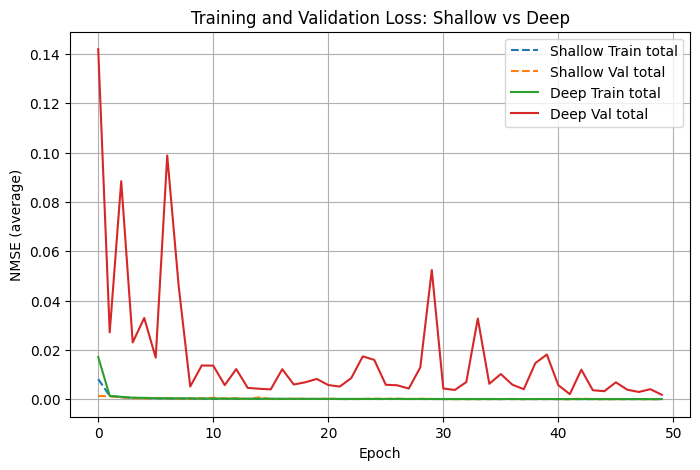

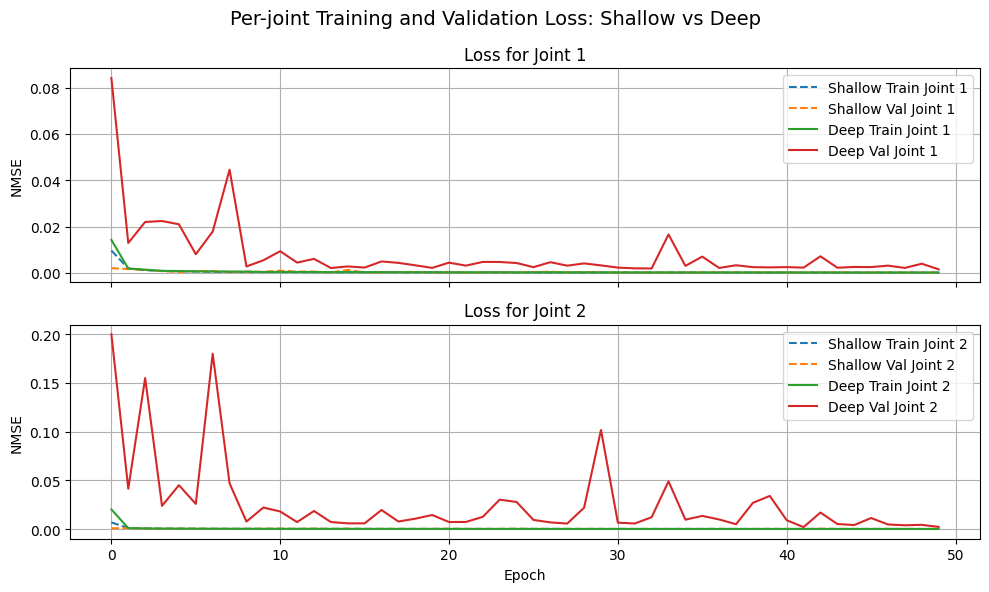

train loss mse + norm 8.13972728792578e-05
val loss mse + norm 6.693819887004793e-05
train loss nmse 0.0001072605446097441
val loss nmse 0.0018348651938140392


In [ ]:
# --- Converto in numpy arrays ---
train_loss_log_shallow = np.array(train_loss_log_shallow)
val_loss_log_shallow   = np.array(val_loss_log_shallow)
train_loss_joints_log_shallow = np.array(train_loss_joints_log_shallow)
val_loss_joints_log_shallow   = np.array(val_loss_joints_log_shallow)

train_loss_log_deep = np.array(train_loss_log_deep)
val_loss_log_deep   = np.array(val_loss_log_deep)
train_loss_joints_log_deep = np.array(train_loss_joints_log_deep)
val_loss_joints_log_deep   = np.array(val_loss_joints_log_deep)

num_epochs_shallow = len(train_loss_log_shallow)
num_epochs_deep    = len(train_loss_log_deep)
n_joints = train_loss_joints_log_shallow.shape[1]

# --- Plot totale ---
plt.figure(figsize=(8, 5))
plt.plot(range(num_epochs_shallow), train_loss_log_shallow, label="Shallow Train total", linestyle="--")
plt.plot(range(num_epochs_shallow), val_loss_log_shallow, label="Shallow Val total", linestyle="--")
plt.plot(range(num_epochs_deep), train_loss_log_deep, label="Deep Train total")
plt.plot(range(num_epochs_deep), val_loss_log_deep, label="Deep Val total")
plt.xlabel("Epoch")
plt.ylabel("NMSE (average)")
plt.title("Training and Validation Loss: Shallow vs Deep")
plt.legend()
plt.grid(True)
plt.show()

# --- Plot per giunto ---
fig, axes = plt.subplots(n_joints, 1, figsize=(10, 3 * n_joints), sharex=True)

if n_joints == 1:
    axes = [axes]

for j in range(n_joints):
    axes[j].plot(range(num_epochs_shallow), train_loss_joints_log_shallow[:, j], label=f"Shallow Train Joint {j+1}", linestyle="--")
    axes[j].plot(range(num_epochs_shallow), val_loss_joints_log_shallow[:, j], label=f"Shallow Val Joint {j+1}", linestyle="--")
    axes[j].plot(range(num_epochs_deep), train_loss_joints_log_deep[:, j], label=f"Deep Train Joint {j+1}")
    axes[j].plot(range(num_epochs_deep), val_loss_joints_log_deep[:, j], label=f"Deep Val Joint {j+1}")
    axes[j].set_ylabel("NMSE")
    axes[j].legend()
    axes[j].grid(True)
    axes[j].set_title(f"Loss for Joint {j+1}")

axes[-1].set_xlabel("Epoch")

plt.suptitle("Per-joint Training and Validation Loss: Shallow vs Deep", fontsize=14)
plt.tight_layout()
plt.show()

print(f"train loss mse + norm {train_loss_log_shallow[-1]}")
print(f"val loss mse + norm {val_loss_log_shallow[-1]}")

print(f"train loss nmse {train_loss_log_deep[-1]}")
print(f"val loss nmse {val_loss_log_deep[-1]}")

## Final testing

=== NETWORK TRAINED ON NORM DATA torque test ===
AVERAGE TEST LOSS: 0.009206611663103104
TEST LOSS JOINTS: [0.00126916 0.01714405]
AVERAGE TEST LOSS nMSE: 6.574272993020713e-05
TEST LOSS JOINTS  nMSE: [9.0821261e-05 4.0664178e-05]
=== NETWORK TRAINED ON NORM DATA normalized test ===
AVERAGE TEST LOSS: 6.454192771343514e-05
TEST LOSS JOINTS: [1.0175601e-04 2.7327922e-05]
AVERAGE TEST LOSS nMSE: 6.574272993020713e-05
TEST LOSS JOINTS  nMSE: [9.0821261e-05 4.0664178e-05]

=== NETWORK TRAINED WITH NMSE torque test ===
AVERAGE TEST LOSS: 0.0054846578277647495
TEST LOSS JOINTS: [0.00099386 0.00997544]
AVERAGE TEST LOSS nMSE: 4.739092764793895e-05
TEST LOSS JOINTS  nMSE: [7.1120907e-05 2.3660854e-05]



NN norm + MSE: 6.574272993020713e-05
NN nMSE: 4.739092764793895e-05


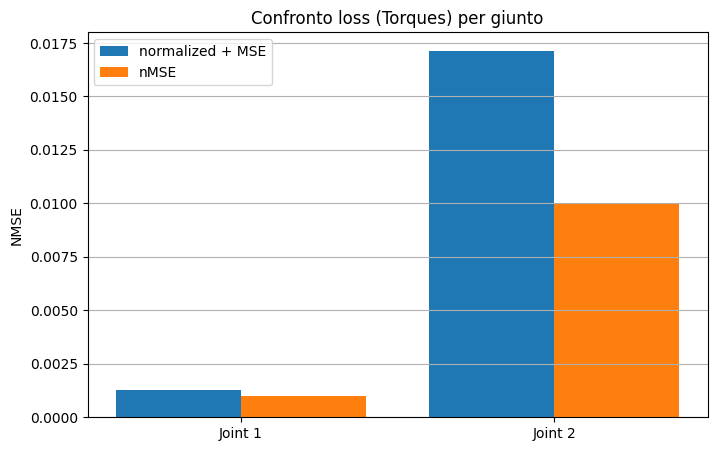

In [ ]:
def evaluate_network(net, test_dataloader, device, mean_y, std_y, test_data_normalized = False):
    """
    Funzione per valutare una rete su test set.
    Ritorna outputs, labels, test_loss medio e per giunto.
    """
    all_inputs = []
    all_outputs = []
    all_labels = []
    test_loss = []
    test_loss_joints = []
    test_loss_nmse = []
    test_loss_joints_nmse = []


    net.eval()  # Evaluation mode (e.g. disable dropout)
    with torch.no_grad():  # Disable gradient tracking
        for sample_batched in test_dataloader:
            # Move data to device
            x_batch = sample_batched[0].to(device)
            label_batch = sample_batched[1].to(device)

            # Forward pass
            out = net(x_batch)

            if not test_data_normalized:
              out = out * std_y + mean_y

            # Loss
            loss_nmse = nmse_loss(out, label_batch)
            loss_nmse_per_joint = nmse_per_joint(out, label_batch)
            loss = loss_fn(out, label_batch)
            loss_per_joints = mse_per_joint(out, label_batch)

            # Save val loss for this batch
            test_loss_nmse.append(loss_nmse.cpu().numpy())
            test_loss_joints_nmse.append(loss_nmse_per_joint.cpu().numpy())
            test_loss.append(loss.cpu().numpy())
            test_loss_joints.append(loss_per_joints.cpu().numpy())

            # Save outputs and labels
            all_inputs.append(x_batch)
            all_outputs.append(out)
            all_labels.append(label_batch)

    # Concatenate all the outputs and labels in a single tensor
    all_inputs  = torch.cat(all_inputs)
    all_outputs = torch.cat(all_outputs)
    all_labels  = torch.cat(all_labels)

    # Media totale e per giunto
    test_loss = np.mean(test_loss)
    test_loss_joints = np.mean(np.vstack(test_loss_joints), axis=0)
    test_loss_nmse = np.mean(test_loss_nmse)
    test_loss_joints_nmse = np.mean(np.vstack(test_loss_joints_nmse), axis=0)

    return all_inputs, all_outputs, all_labels, test_loss, test_loss_joints, test_loss_nmse, test_loss_joints_nmse

mean_y_tensor = torch.tensor(mean_y).float().to(device)
std_y_tensor = torch.tensor(std_y).float().to(device)


# --- Valutazione rete normalizzata comparando le toques ---
inputs_shallow, outputs_shallow, labels_shallow, test_loss_shallow, test_loss_joints_shallow, test_loss_nmse_shallow, test_loss_joints_nmse_shallow = evaluate_network(
    net_shallow, test_dataloader, device, mean_y_tensor, std_y_tensor
)

# --- Valutazione rete normalizzata, rispetto a test dataset normalizzato ---
inputs_shallow_norm, outputs_shallow_norm, labels_shallow_norm, test_loss_shallow_norm, test_loss_joints_shallow_norm, test_loss_nmse_shallow_norm, test_loss_joints_nmse_shallow_norm = evaluate_network(
    net_shallow, test_dataloader_norm, device, mean_y_tensor, std_y_tensor, test_data_normalized=True
)

print("=== NETWORK TRAINED ON NORM DATA torque test ===")
print(f"AVERAGE TEST LOSS: {test_loss_shallow}")
print(f"TEST LOSS JOINTS: {test_loss_joints_shallow}")
print(f"AVERAGE TEST LOSS nMSE: {test_loss_nmse_shallow}")
print(f"TEST LOSS JOINTS  nMSE: {test_loss_joints_nmse_shallow}")

print("=== NETWORK TRAINED ON NORM DATA normalized test ===")
print(f"AVERAGE TEST LOSS: {test_loss_shallow_norm}")
print(f"TEST LOSS JOINTS: {test_loss_joints_shallow_norm}")
print(f"AVERAGE TEST LOSS nMSE: {test_loss_nmse_shallow}")
print(f"TEST LOSS JOINTS  nMSE: {test_loss_joints_nmse_shallow}")

# --- Valutazione rete deep ---
inputs_deep, outputs_deep, labels_deep, test_loss_deep, test_loss_joints_deep, test_loss_nmse_deep, test_loss_joints_nmse_deep = evaluate_network(net_deep, test_dataloader, device, mean_y_tensor, std_y_tensor, test_data_normalized=True)
print("\n=== NETWORK TRAINED WITH NMSE torque test ===")
print(f"AVERAGE TEST LOSS: {test_loss_deep}")
print(f"TEST LOSS JOINTS: {test_loss_joints_deep}")
print(f"AVERAGE TEST LOSS nMSE: {test_loss_nmse_deep}")
print(f"TEST LOSS JOINTS  nMSE: {test_loss_joints_nmse_deep}")


print("\n\n")
print(f"NN norm + MSE: {test_loss_nmse_shallow}")
print(f"NN nMSE: {test_loss_nmse_deep}")


# --- Confronto grafico per giunto ---
n_joints = test_loss_joints_shallow.shape[0]
x = np.arange(n_joints)

plt.figure(figsize=(8,5))
plt.bar(x - 0.2, test_loss_joints_shallow, width=0.4, label="normalized + MSE")
plt.bar(x + 0.2, test_loss_joints_deep, width=0.4, label="nMSE")
plt.xticks(x, [f"Joint {i+1}" for i in range(n_joints)])
plt.ylabel("NMSE")
plt.title("Confronto loss (Torques) per giunto")
plt.legend()
plt.grid(True, axis="y")
plt.show()

